#### Getting Started with Adversarial Robustness Toolbox (ART) using PyTorch

Based on this script: https://github.com/Trusted-AI/adversarial-robustness-toolbox/blob/main/examples/get_started_pytorch.py

In [1]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import PyTorchClassifier
from art.utils import load_mnist

import matplotlib.pyplot as plt
from localized_classmap import plotExplanations

/home/nura-kawa/Projects/localized-classmap/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Model Building 
Define the neural network model, return logits instead of activation in forward method

In [2]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv_1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=5, stride=1)
        self.conv_2 = nn.Conv2d(in_channels=4, out_channels=10, kernel_size=5, stride=1)
        self.fc_1 = nn.Linear(in_features=4 * 4 * 10, out_features=100)
        self.fc_2 = nn.Linear(in_features=100, out_features=10)

    def forward(self, x):
        x = F.relu(self.conv_1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv_2(x))
        x = F.max_pool2d(x, 2, 2)
        x = x.view(-1, 4 * 4 * 10)
        x = F.relu(self.fc_1(x))
        x = self.fc_2(x)
        return x

In [3]:
# Load MNIST

(x_train, y_train), (x_test, y_test), min_pixel_value, max_pixel_value = load_mnist()

# Swap axes to PyTorch's NCHW format

x_train = np.transpose(x_train, (0, 3, 1, 2)).astype(np.float32)
x_test = np.transpose(x_test, (0, 3, 1, 2)).astype(np.float32)

In [4]:
model = Net()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Initialize the classifier

classifier = PyTorchClassifier(
    model=model,
    clip_values=(min_pixel_value, max_pixel_value),
    loss=criterion,
    optimizer=optimizer,
    input_shape=(1, 28, 28),
    nb_classes=10,
)

/home/nura-kawa/Projects/localized-classmap/env/lib/python3.12/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [5]:
# Train the classifier
classifier.fit(x_train, y_train, batch_size=64, nb_epochs=3)

In [82]:
predictions = classifier.predict(x_test)
accuracy = np.sum(np.argmax(predictions, axis=1) == np.argmax(y_test, axis=1)) / len(y_test)
print("Accuracy on benign test examples: {}%".format(accuracy * 100))

Accuracy on benign test examples: 98.17%


#### Adversarial Examples Generation with ART

In [74]:
attack = FastGradientMethod(estimator=classifier, eps=0.05)
x_test_adv = attack.generate(x=x_test.copy())

In [75]:
# Evaluate classifier on test examples
predictions = classifier.predict(x_test_adv)
accuracy = np.sum(np.argmax(predictions, axis=1) == np.argmax(y_test, axis=1)) / len(y_test)
print("Accuracy on adversarial test examples: {}%".format(accuracy * 100))


Accuracy on adversarial test examples: 90.06%


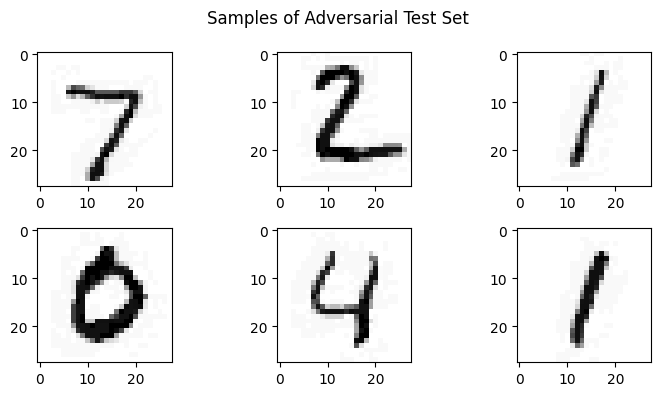

In [76]:
# Visualize Adversarial Examples

num_row = 2
num_col = 3

# plot images: atypical examples of class 9
fig, axes = plt.subplots(num_row, num_col,
                         figsize=(2.5*num_col,2*num_row))
for i in range(6):
    ax = axes[i//num_col, i%num_col]
    img = x_test_adv[i,...].squeeze()
    ax.imshow(img, cmap='Greys')
fig.suptitle('Samples of Adversarial Test Set')
plt.tight_layout()
plt.show()

PAC Computed
Flattening data
Searching for 40 nearest neighbors for 10000 points. This could take some time!
Nearest neighbor search complete !
LF Computed


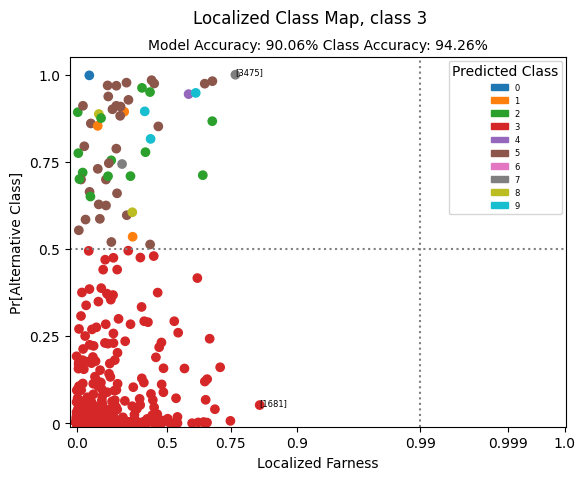

In [79]:
# plot explanations
# we can plot a localized class map for each class
# because it is quite slow to perform a nearest neighbor search
# for 10,000 points, we only look at class 3 and class 9

# source localized classmap
exec(open('localized_classmap.py').read())

# class 3 adversarial
plotExplanations(model=classifier,
                 X=x_test_adv,
                 y=np.argmax(y_test, axis=1),
                 k=40,
                 cl=3,
                 annotate=True,
                 pytorch=True)


PAC Computed
Flattening data
Searching for 40 nearest neighbors for 10000 points. This could take some time!
Nearest neighbor search complete !
LF Computed


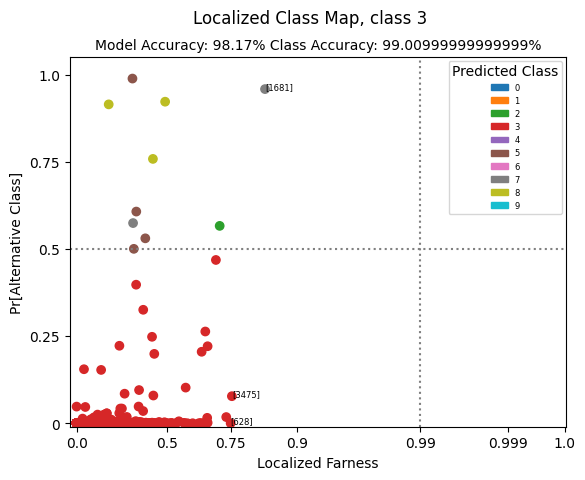

In [83]:
(x_train, y_train), (x_test, y_test), min_pixel_value, max_pixel_value = load_mnist()

# Swap axes to PyTorch's NCHW format

x_train = np.transpose(x_train, (0, 3, 1, 2)).astype(np.float32)
x_test = np.transpose(x_test, (0, 3, 1, 2)).astype(np.float32)
del(x_test_adv)
# class 3 benign
plotExplanations(model=classifier,
                 X=x_test,
                 y=np.argmax(y_test, axis=1),
                 k=40,
                 cl=3,
                 annotate=True,
                 pytorch=True)
